# <데이터 전처리>

# [과정 요약]
##[0 단계]
### -  건고추 '화건'종 제외한 나머지 종 train.csv에서 행 삭제 -> 다행히 '화건' 종 행의 평균 가격만 가격이 채워져있음.
## [1단계]
### - train.csv에서 타겟 값이 0인 행 중 메타 데이터를 통해 전국 도매 단가(원/kg) 구할 수 있는 것은 그거로 평균 가격 보간
### - 다만, 사과, 배는 test 데이터에서 단위가 '개' 이기 때문에 그대로 둠

## [2단계] 최근 가격 추세 보간
### - '전순 평균가'와 '전달 평균가' 활용
### - 우선 순위는 '전순' 없다면 '전달'

## [3단계]
### - 위 2단계에도 해당하지 않은 데이터 경우
### - '전년 평균 가격' 과 '평년 평균 가격' 으로 보간


In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import glob
import os

# 1. 구글 드라이브 마운트
# (이미 마운트되어 있더라도 다시 실행하면 연결 상태를 확인합니다.)
drive.mount('/content/drive')

# 2. 작업 경로 설정
base_path = '/content/drive/MyDrive/26_1_DScover/GuideProject'
os.chdir(base_path)

print(f"현재 작업 경로: {os.getcwd()}")
print("폴더 내 파일 목록:", os.listdir('./data/train'))

# 3. 정답 데이터(train.csv) 로드
train_df = pd.read_csv('./data/train/train.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
현재 작업 경로: /content/drive/MyDrive/26_1_DScover/GuideProject
폴더 내 파일 목록: ['meta', 'train.csv', 'train_remove_pepper.csv', 'train_step1.csv', 'train_step2.csv', 'train_step3_final.csv', 'train_target_only.csv']



## [0 단계] 건고추 '화건'종 제외한 나머지 종 train.csv에서 행 삭제 -> 다행히 '화건' 종 행의 평균 가격만 가격이 채워져있음.

In [2]:
import pandas as pd

# 데이터 경로 설정 (농산물 프로젝트 구조 반영)
# train.csv는 ./data/train/ 폴더 내에 위치함
file_path = './data/train/train.csv'

# 1. 데이터 로드
df = pd.read_csv(file_path)

# 2. 건고추 품목 노이즈 제거
# 건고추 품목 중 타겟 조건(화건, 30 kg, 상품)에 해당하지 않는 행 필터링
is_pepper = (df['품목명'] == '건고추')
is_target_pepper = (df['품종명'] == '화건') & (df['거래단위'] == '30 kg') & (df['등급'] == '상품')

# 건고추이면서 타겟이 아닌 행들만 식별하여 데이터프레임에서 제외
# 건고추 외 다른 품목들은 그대로 유지
noise_pepper_idx = df[is_pepper & ~is_target_pepper].index
df_refined = df.drop(noise_pepper_idx)

# 3. 중간 결과 저장
# 건고추 노이즈가 제거된 데이터를 이후 프로세스를 위해 드라이브에 저장
output_path = './data/train/train_remove_pepper.csv'
df_refined.to_csv(output_path, index=False)

print(f"Step 0 완료: {len(noise_pepper_idx)}개의 건고추 노이즈 행 제거됨")
print(f"결과 저장 완료: {output_path}")

Step 0 완료: 1008개의 건고추 노이즈 행 제거됨
결과 저장 완료: ./data/train/train_remove_pepper.csv


## 1단계
### - train.csv에서 타겟 값이 0인 행 중 메타 데이터를 통해 전국 도매 단가(원/kg) 구할 수 있는 것은 그거로 평균 가격 보간
### - 다만, 사과, 배는 test 데이터에서 단위가 '개' 이기 때문에 그대로 둠

In [3]:
import pandas as pd
import numpy as np
import re

# 1. 데이터 로드
# Step 0에서 생성한 정제 파일과 전국도매 메타데이터 로드
train = pd.read_csv('./data/train/train_remove_pepper.csv')
wholesale = pd.read_csv('./data/train/meta/TRAIN_전국도매_2018-2021.csv')

# 2. 전국도매 데이터 일별 단가(원/kg) 산출
wholesale_daily = wholesale.groupby(['시점', '품목명', '품종명']).agg({
    '총반입량(kg)': 'sum',
    '총거래금액(원)': 'sum'
}).reset_index()

# 1순위: 총거래금액 / 총반입량으로 당일 단가(원/kg) 계산
wholesale_daily['도매_단가_kg'] = 0.0
valid_mask = wholesale_daily['총반입량(kg)'] > 0
wholesale_daily.loc[valid_mask, '도매_단가_kg'] = \
    wholesale_daily.loc[valid_mask, '총거래금액(원)'] / wholesale_daily.loc[valid_mask, '총반입량(kg)']

# 3. 데이터 병합 (Key: 시점, 품목명, 품종명)
train['시점'] = train['시점'].astype(str)
wholesale_daily['시점'] = wholesale_daily['시점'].astype(str)

train = train.merge(
    wholesale_daily[['시점', '품목명', '품종명', '도매_단가_kg']],
    on=['시점', '품목명', '품종명'],
    how='left'
)

# 4. 거래단위별 kg 환산 중량 추출 함수
def extract_weight(unit):
    unit_str = str(unit)
    if '100 g' in unit_str:
        return 0.1
    # 정규표현식을 통해 숫자 부분만 추출
    nums = re.findall(r'\d+\.?\d*', unit_str)
    if nums:
        return float(nums[0])
    return 1.0

# 임시 중량 컬럼 생성
train['temp_weight'] = train['거래단위'].apply(extract_weight)

# 5. 1순위 보간 실행
# 사과와 배는 단위(10 개) 특성상 도매 단가(kg) 적용 시 오차 우려로 제외
fill_mask = ((train['평균가격(원)'] == 0) | (train['평균가격(원)'].isna())) & \
            (~train['품목명'].isin(['사과', '배']))

# 도매 단가(원/kg) * 원래 거래단위 중량 적용
train.loc[fill_mask, '평균가격(원)'] = train.loc[fill_mask, '도매_단가_kg'] * train.loc[fill_mask, 'temp_weight']

# 6. 중간 결과 저장 (매우 중요!)
# 불필요 컬럼 제거 후 다음 단계를 위해 파일로 저장
train.drop(columns=['도매_단가_kg', 'temp_weight'], inplace=True)
train.to_csv('./data/train/train_step1.csv', index=False)

print("Step 1 완료 및 './data/train/train_step1.csv' 저장 성공.")

Step 1 완료 및 './data/train/train_step1.csv' 저장 성공.


In [4]:
import pandas as pd

# 1단계 결과 파일 로드
df_step1 = pd.read_csv('./data/train/train_step1.csv')

# 우리가 관리하는 10개 타겟 품목
target_items = ['건고추', '사과', '감자', '배', '깐마늘(국산)', '무', '상추', '배추', '양파', '대파']

print("--- [진단] 1순위 보간 후 결측치 현황 ---")
for item in target_items:
    item_df = df_step1[df_step1['품목명'] == item]
    # 0원 또는 NaN인 경우를 모두 결측치로 간주
    missing_mask = (item_df['평균가격(원)'] <= 0) | (item_df['평균가격(원)'].isna())
    missing_count = missing_mask.sum()
    total_count = len(item_df)

    print(f"[{item:8}] 결측치: {missing_count:4} / 전체: {total_count:4} ({(missing_count/total_count)*100:5.2f}%)")

print("-" * 40)

--- [진단] 1순위 보간 후 결측치 현황 ---
[건고추     ] 결측치:    0 / 전체:  144 ( 0.00%)
[사과      ] 결측치:  399 / 전체:  720 (55.42%)
[감자      ] 결측치: 2178 / 전체: 4752 (45.83%)
[배       ] 결측치:  262 / 전체:  576 (45.49%)
[깐마늘(국산) ] 결측치:    0 / 전체:  288 ( 0.00%)
[무       ] 결측치:   72 / 전체: 4752 ( 1.52%)
[상추      ] 결측치:    0 / 전체:  576 ( 0.00%)
[배추      ] 결측치:  356 / 전체: 3744 ( 9.51%)
[양파      ] 결측치: 1652 / 전체: 9792 (16.87%)
[대파      ] 결측치:  375 / 전체: 3024 (12.40%)
----------------------------------------


## [2단계] 최근 가격 추세 보간
### - '전순 평균가'와 '전달 평균가' 활용
### - 우선 순위는 '전순' 없다면 '전달'


In [5]:
import pandas as pd
import numpy as np
import re

# 1. 데이터 로드 (Step 1 결과물 및 메타데이터 2종 활용)
base_path = './data/train/'
train = pd.read_csv(base_path + 'train_step1.csv')
wholesale = pd.read_csv(base_path + 'meta/TRAIN_전국도매_2018-2021.csv')
sanji = pd.read_csv(base_path + 'meta/TRAIN_산지공판장_2018-2021.csv')

# 2. 도매 및 산지 추세 데이터 전처리
# 도매 데이터 추세 집계
w_trend = wholesale.groupby(['시점', '품목명', '품종명']).agg({
    '전순 평균가격(원) PreVious SOON': 'mean',
    '전달 평균가격(원) PreVious MMonth': 'mean'
}).reset_index()

# 산지 데이터 추세 집계
s_trend = sanji.groupby(['시점', '품목명', '품종명']).agg({
    '전순 평균가격(원) PreVious SOON': 'mean',
    '전달 평균가격(원) PreVious MMonth': 'mean'
}).reset_index()

# 3. 데이터 병합 (Key 타입 통일 후 순차 Merge)
train['시점'] = train['시점'].astype(str)
w_trend['시점'] = w_trend['시점'].astype(str)
s_trend['시점'] = s_trend['시점'].astype(str)

train = train.merge(w_trend, on=['시점', '품목명', '품종명'], how='left')
train = train.merge(s_trend, on=['시점', '품목명', '품종명'], how='left', suffixes=('_도매', '_산지'))

# 4. 중량 추출 함수
def extract_weight(unit):
    unit_str = str(unit)
    if '100 g' in unit_str: return 0.1
    nums = re.findall(r'\d+\.?\d*', unit_str)
    return float(nums[0]) if nums else 1.0

train['temp_weight'] = train['거래단위'].apply(extract_weight)

# 5. 2순위 보간 로직 (도매 추세 -> 산지 추세 순)
# 사과, 배는 단위 이슈로 이번 단계에서도 제외
fill_mask = ((train['평균가격(원)'] == 0) | (train['평균가격(원)'].isna())) & \
            (~train['품목명'].isin(['사과', '배']))

# 우선순위: 도매 전순 -> 산지 전순 -> 도매 전달 -> 산지 전달
trend_val = train['전순 평균가격(원) PreVious SOON_도매'].fillna(
    train['전순 평균가격(원) PreVious SOON_산지']
).fillna(
    train['전달 평균가격(원) PreVious MMonth_도매']
).fillna(
    train['전달 평균가격(원) PreVious MMonth_산지']
)

train.loc[fill_mask, '평균가격(원)'] = trend_val[fill_mask] * train.loc[fill_mask, 'temp_weight']

# 6. 결과 확인 및 저장
target_items = ['건고추', '사과', '감자', '배', '깐마늘(국산)', '무', '상추', '배추', '양파', '대파']
print("--- [Step 2 수정] 보간 후 타겟 품목별 결측치 현황 ---")
for item in target_items:
    item_df = train[train['품목명'] == item]
    missing = ((item_df['평균가격(원)'] <= 0) | (item_df['평균가격(원)'].isna())).sum()
    print(f"{item:8}: {missing:4} / {len(item_df):4} 건")

# 불필요 컬럼 정리
drop_cols = [c for c in train.columns if 'PreVious' in c] + ['temp_weight']
train.drop(columns=drop_cols, inplace=True)
train.to_csv(base_path + 'train_step2.csv', index=False)

--- [Step 2 수정] 보간 후 타겟 품목별 결측치 현황 ---
건고추     :    0 /  144 건
사과      :  399 /  720 건
감자      : 2178 / 4752 건
배       :  262 /  576 건
깐마늘(국산) :    0 /  288 건
무       :   72 / 4752 건
상추      :    0 /  576 건
배추      :  356 / 3744 건
양파      : 1620 / 9792 건
대파      :  375 / 3024 건


## [3단계]
### - 위 2단계에도 해당하지 않은 데이터 경우
### - '전년 평균 가격' 과 '평년 평균 가격' 으로 보간

In [6]:
import pandas as pd
import numpy as np
import re

# 1. 데이터 로드 (Step 2 결과물 및 메타데이터 활용)
base_path = './data/train/'
train = pd.read_csv(base_path + 'train_step2.csv')
wholesale = pd.read_csv(base_path + 'meta/TRAIN_전국도매_2018-2021.csv')

# 2. 전년 및 평년 가격 데이터 집계
# '전년 평균가격(원) PreVious YeaR', '평년 평균가격(원) Common Year SOON' 활용
reference_year = wholesale.groupby(['시점', '품목명', '품종명']).agg({
    '전년 평균가격(원) PreVious YeaR': 'mean',
    '평년 평균가격(원) Common Year SOON': 'mean'
}).reset_index()

# 3. 데이터 병합
train['시점'] = train['시점'].astype(str)
reference_year['시점'] = reference_year['시점'].astype(str)
train = train.merge(reference_year, on=['시점', '품목명', '품종명'], how='left')

# 4. 중량 추출 함수 (사과/배 특수처리 포함)
def get_weight(row):
    unit = str(row['거래단위'])
    if '10개' in unit.replace(" ", ""): # '10 개' 또는 '10개' 대응
        return 3.0 if row['품목명'] == '사과' else 5.0
    if '100 g' in unit: return 0.1
    nums = re.findall(r'\d+\.?\d*', unit)
    return float(nums[0]) if nums else 1.0

train['temp_weight'] = train.apply(get_weight, axis=1)

# 5. Step 3 보간 실행 (전년 -> 평년 순)
# 여전히 가격이 0원인 모든 품목 대상 (필터링 없음)
fill_mask = (train['평균가격(원)'] <= 0) | (train['평균가격(원)'].isna())

# 전년 가격을 먼저 쓰고, 없으면 평년(5년 평균) 가격으로 보강
historical_val = train['전년 평균가격(원) PreVious YeaR'].fillna(train['평년 평균가격(원) Common Year SOON'])
train.loc[fill_mask, '평균가격(원)'] = historical_val[fill_mask] * train.loc[fill_mask, 'temp_weight']

# 6. 이상치(Outlier) 제거 - IQR 방식
# 데이터의 통계적 분포를 사용하여 비정상적으로 높거나 낮은 값 제거
#
def clean_outliers(df, col):
    # 품목별로 가격 편차가 크므로 품목별로 그룹화하여 이상치 제거
    def get_cleaned_group(group):
        q1 = group[col].quantile(0.01) # 하위 1%
        q3 = group[col].quantile(0.99) # 상위 1%
        return group[(group[col] > q1) & (group[col] < q3)]

    return df.groupby('품목명', group_keys=False).apply(get_cleaned_group)

print(f"이상치 제거 전 행 수: {len(train)}")
# 가격이 0원인 데이터는 학습에 방해되므로 제외 후 이상치 제거
train_final = clean_outliers(train[train['평균가격(원)'] > 0], '평균가격(원)')
print(f"이상치 제거 후 행 수: {len(train_final)}")

# 7. 컬럼 정리 및 최종 저장
drop_cols = ['전년 평균가격(원) PreVious YeaR', '평년 평균가격(원) Common Year SOON', 'temp_weight']
train_final.drop(columns=drop_cols, inplace=True)
train_final.to_csv(base_path + 'train_step3_final.csv', index=False)


이상치 제거 전 행 수: 28368
이상치 제거 후 행 수: 22726


/tmp/ipykernel_21475/21791993.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('품목명', group_keys=False).apply(get_cleaned_group)


##[결측치 확인]
### 없음 확인

In [7]:
import pandas as pd

# 1. 최종 저장된 파일 로드
df_final = pd.read_csv('./data/train/train_step3_final.csv')

# 2. 전체 데이터 기준 결측치 체크
total_nan = df_final['평균가격(원)'].isna().sum()
total_zero = (df_final['평균가격(원)'] == 0).sum()

print("--- [전체 데이터셋 상태 보고] ---")
print(f"전체 행 수: {len(df_final):,} 건")
print(f"NaN(결측치) 개수: {total_nan:,} 건")
print(f"0원 데이터 개수: {total_zero:,} 건")
print("-" * 30)

# 3. 우리가 신경 써야 할 10개 타겟 품목별 상세 현황
target_items = ['건고추', '사과', '감자', '배', '깐마늘(국산)', '무', '상추', '배추', '양파', '대파']

print("\n--- [타겟 품목별 미해결 결측치 현황] ---")
summary_list = []
for item in target_items:
    item_df = df_final[df_final['품목명'] == item]
    missing = ((item_df['평균가격(원)'] <= 0) | (item_df['평균가격(원)'].isna())).sum()
    total = len(item_df)
    ratio = (missing / total) * 100 if total > 0 else 0
    summary_list.append([item, missing, total, f"{ratio:.2f}%"])

summary_table = pd.DataFrame(summary_list, columns=['품목명', '결측치(0원 포함)', '전체 행', '결측률'])
print(summary_table.to_string(index=False))

# 4. (보너스) 여전히 0원이 남았다면? 샘플 확인
if (total_nan + total_zero) > 0:
    print("\n--- [미해결 샘플 확인] ---")
    print(df_final[df_final['평균가격(원)'] <= 0][['시점', '품목명', '품종명', '거래단위']].head(10))

--- [전체 데이터셋 상태 보고] ---
전체 행 수: 22,726 건
NaN(결측치) 개수: 0 건
0원 데이터 개수: 0 건
------------------------------

--- [타겟 품목별 미해결 결측치 현황] ---
    품목명  결측치(0원 포함)  전체 행   결측률
    건고추           0   140 0.00%
     사과           0   360 0.00%
     감자           0  2520 0.00%
      배           0   354 0.00%
깐마늘(국산)           0   282 0.00%
      무           0  4583 0.00%
     상추           0   564 0.00%
     배추           0  3320 0.00%
     양파           0  8008 0.00%
     대파           0  2595 0.00%


# 예측해야하는 타겟 (품목, 품종, 단위, 등급) 만족하는 데이터만 분리해서 파일 저장

In [8]:
import pandas as pd

# 1. 3단계까지 보간이 완료된 전체 데이터 로드
base_path = './data/train/'
# 만약 파일명이 다르다면 현재 가지고 계신 최종 파일명으로 수정해 주세요.
df = pd.read_csv(base_path + 'train_step3_final.csv')

target_conditions = [
    ('건고추', '화건', '30 kg', '상품'),
    ('사과', '홍로', '10 개', '상품'),
    ('사과', '후지', '10 개', '상품'),
    ('감자', '감자 수미', '20키로상자', '상'),
    ('배', '신고', '10 개', '상품'),
    ('깐마늘(국산)', '깐마늘(국산)', '20 kg', '상품'),
    ('무', '무', '20키로상자', '상'),
    ('상추', '청', '100 g', '상품'),
    ('배추', '배추', '10키로망대', '상'),
    ('양파', '양파', '1키로', '상'),
    ('대파', '대파(일반)', '1키로단', '상')
]

# 3. 조건에 맞는 데이터만 뽑아내기
target_dfs = []
for p, v, u, g in target_conditions:
    # 띄어쓰기 등으로 인한 매칭 오류를 방지하기 위해 꼼꼼하게 필터링
    mask = (df['품목명'] == p) & \
           (df['품종명'] == v) & \
           (df['거래단위'] == u) & \
           (df['등급'] == g)

    filtered_df = df[mask]
    target_dfs.append(filtered_df)

# 4. 뽑아낸 데이터 하나로 합치기
target_final_df = pd.concat(target_dfs, ignore_index=True)

# 5. 타겟 전용 파일로 따로 저장
save_path = base_path + 'train_target_only.csv'
target_final_df.to_csv(save_path, index=False)

# 결과 확인
print(f"타겟 데이터 추출 완료!")
print(f"전체 {len(df):,}개 데이터 중 타겟 조건에 맞는 {len(target_final_df):,}개의 데이터만 분리했습니다.")
print(f"저장 위치: {save_path}")

# 각 품목별로 몇 개씩 뽑혔는지 확인
print("\n--- [추출된 타겟 품목별 데이터 수] ---")
print(target_final_df.groupby(['품목명', '품종명']).size().reset_index(name='데이터 수').to_string(index=False))

타겟 데이터 추출 완료!
전체 22,726개 데이터 중 타겟 조건에 맞는 1,425개의 데이터만 분리했습니다.
저장 위치: ./data/train/train_target_only.csv

--- [추출된 타겟 품목별 데이터 수] ---
    품목명     품종명  데이터 수
     감자   감자 수미    140
    건고추      화건    140
깐마늘(국산) 깐마늘(국산)    141
     대파  대파(일반)    144
      무       무    144
      배      신고    144
     배추      배추    144
     사과      홍로     19
     사과      후지    125
     상추       청    140
     양파      양파    144


# 가격 변동 확인

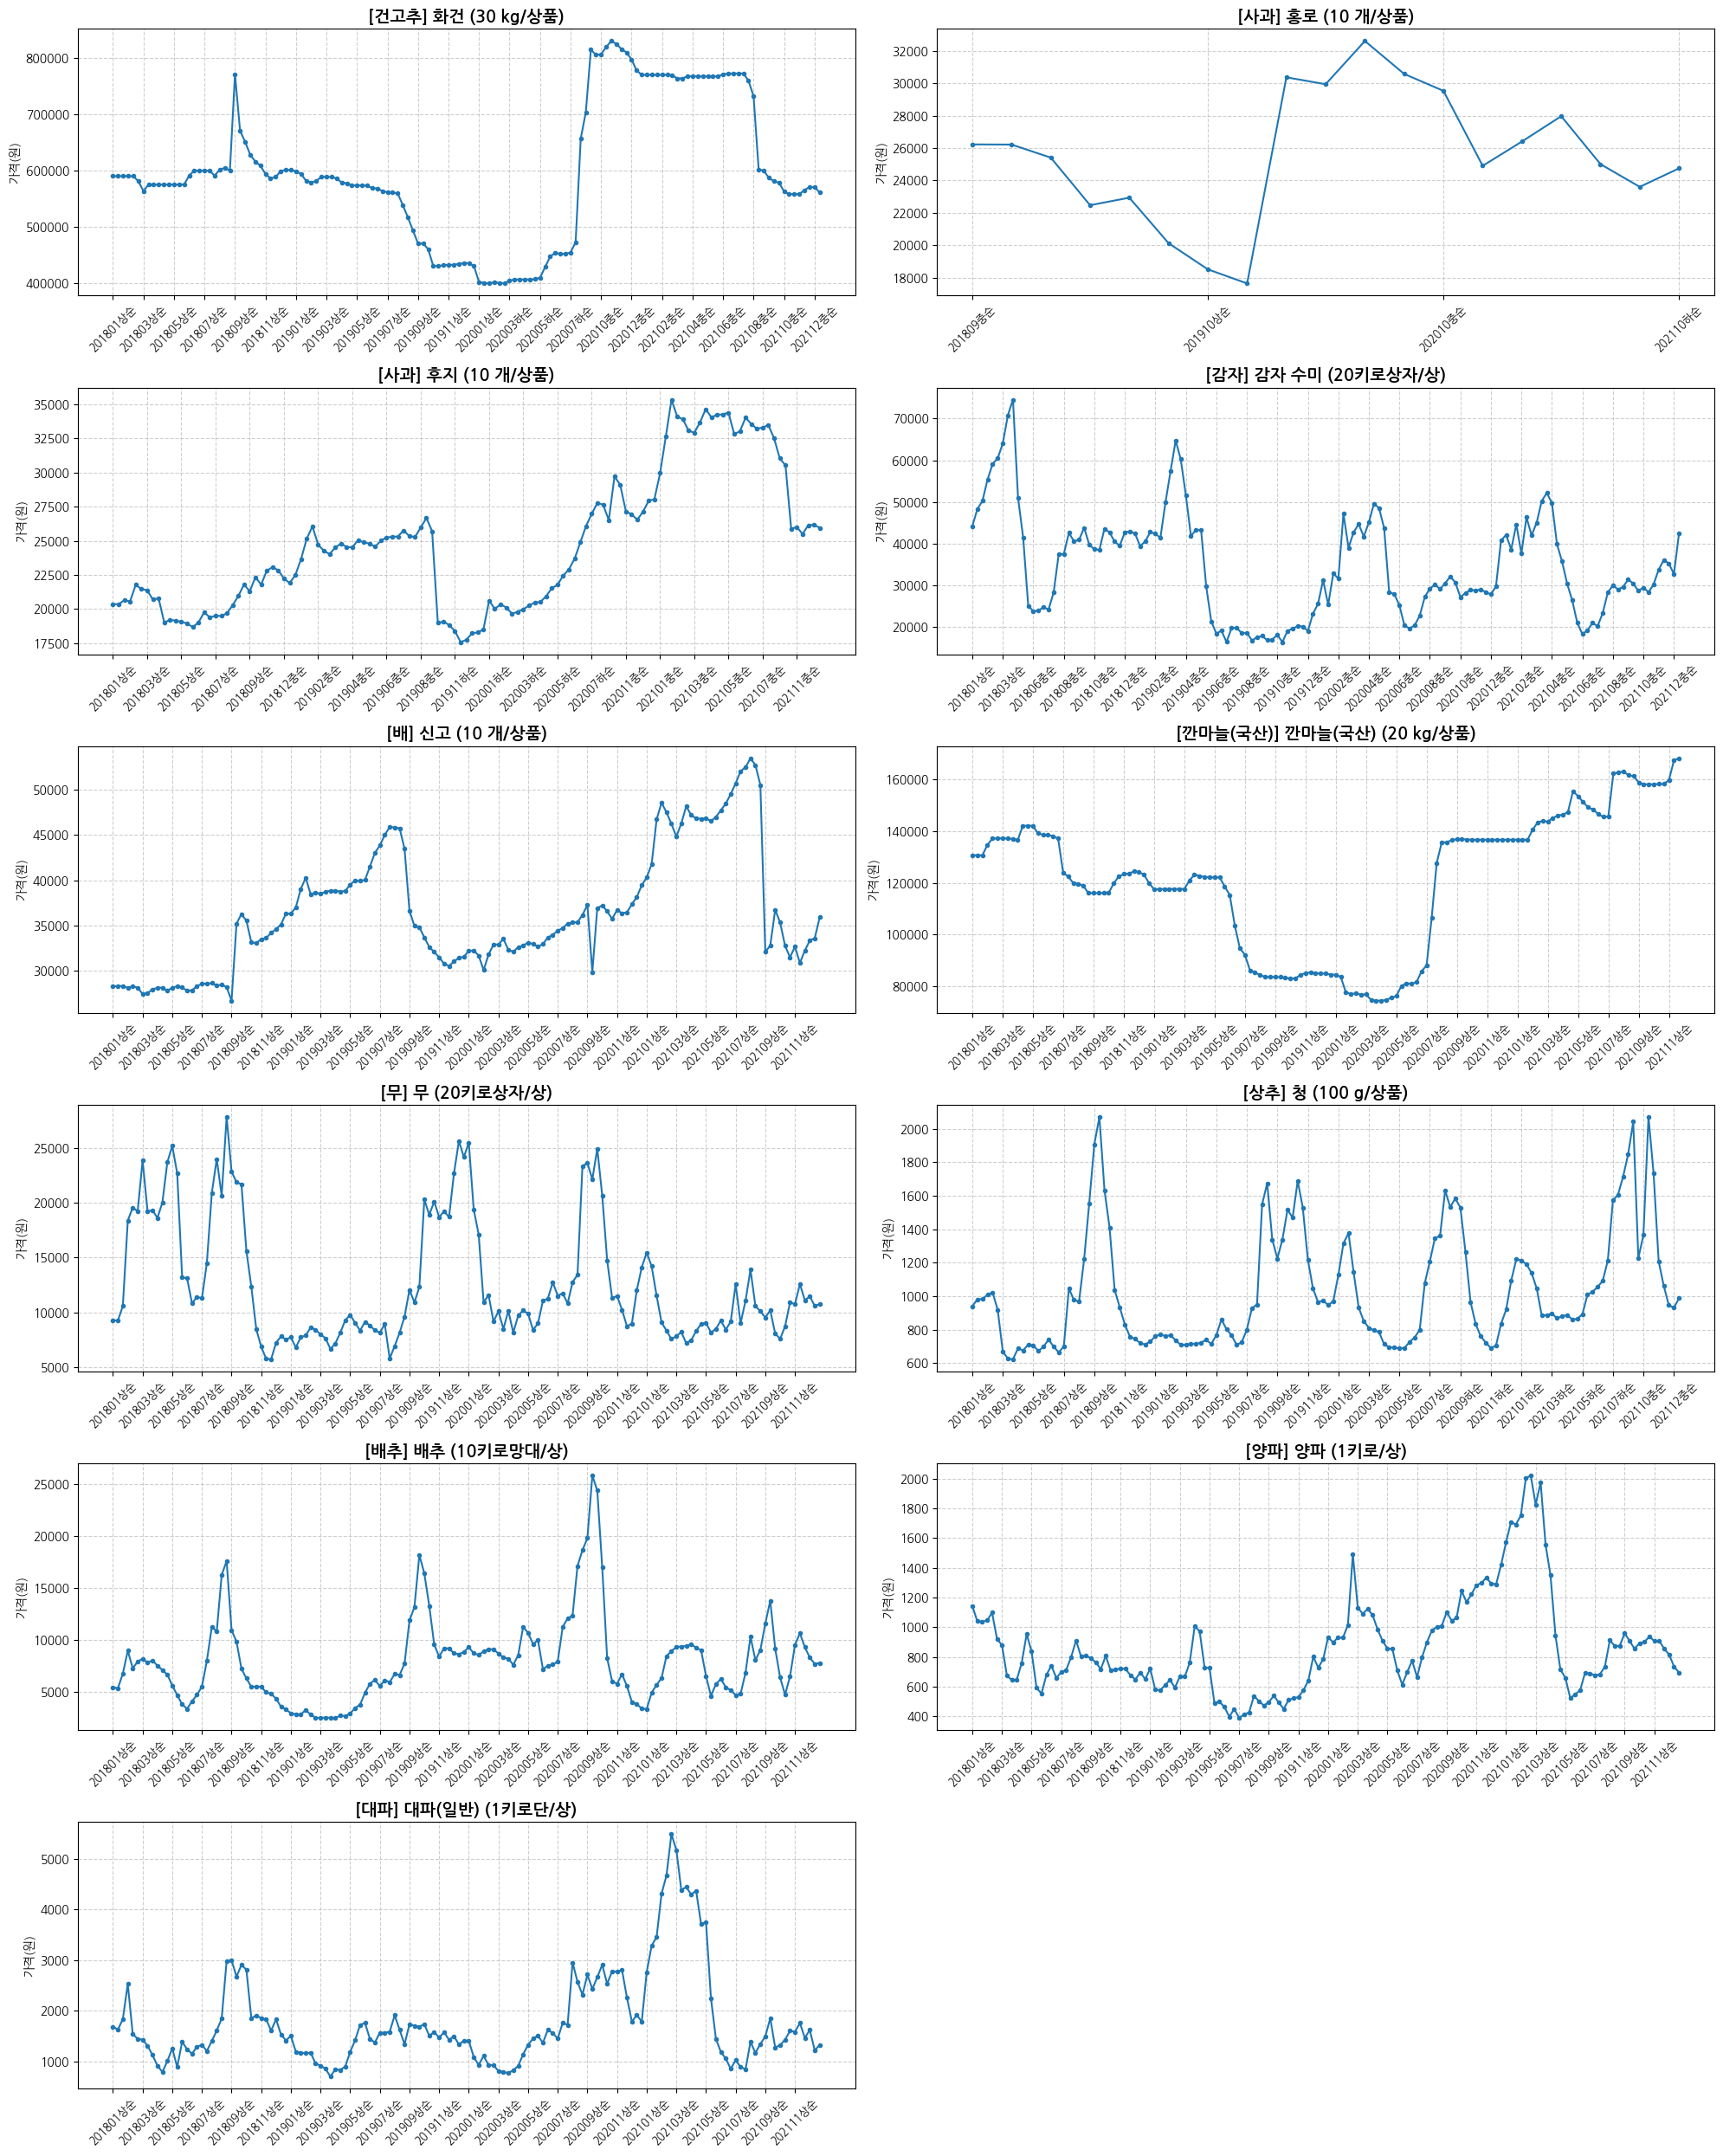

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. 폰트 설정 (나눔고딕)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 타겟 전용 데이터 로드
base_path = './data/train/'
df = pd.read_csv(base_path + 'train_target_only.csv')

# 3. Y축(가격)만 숫자로 깔끔하게 변환 (콤마 제거)
price_col = df.columns[-1]
if df[price_col].dtype == 'object':
    df[price_col] = df[price_col].astype(str).str.replace(',', '')
df[price_col] = pd.to_numeric(df[price_col], errors='coerce')

# 가격이 없는 찌꺼기 데이터는 시각화에서 제외
df = df.dropna(subset=['시점', price_col])

# 4. 고유한 타겟 그룹 식별
target_groups = df[['품목명', '품종명', '거래단위', '등급']].drop_duplicates().values.tolist()

# 5. 시각화 그리기
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(20, 25))
axes = axes.flatten()

for i, (p, v, u, g) in enumerate(target_groups):
    ax = axes[i]

    # 데이터 필터링
    plot_df = df[(df['품목명'] == p) & (df['품종명'] == v) & \
                 (df['거래단위'] == u) & (df['등급'] == g)].copy()

    plot_df = plot_df.sort_values('시점')

    # X축 문자열 그대로, Y축 가격으로 선 그래프 그리기
    ax.plot(plot_df['시점'], plot_df[price_col], marker='o', markersize=3, color='tab:blue', linewidth=1.5)

    # 그래프 꾸미기
    ax.set_title(f'[{p}] {v} ({u}/{g})', fontsize=14, fontweight='bold')
    ax.set_ylabel('가격(원)')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ticks = ax.get_xticks()
    ax.set_xticks(ticks[::6])

# 남는 빈 그래프 공간 지우기
if len(target_groups) < len(axes):
    for j in range(len(target_groups), len(axes)):
        fig.delaxes(axes[j])

# 화면 출력
plt.tight_layout()
plt.show()

#[이상치 처리]
## 상하위 1% 가격 상한선으로 기준 컷팅 -> 상위 1% 값으로 대체

In [17]:
import pandas as pd
import numpy as np

base_path = './data/train/'

# 1. 이상치 처리(Winsorizing) 함수 정의
def apply_winsorization(df, price_col):
    # 가격 컬럼이 문자로 꼬여있다면 숫자형으로 강제 변환
    if df[price_col].dtype == 'object':
        df[price_col] = df[price_col].astype(str).str.replace(',', '')
    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')

    # 그룹별로 상하위 1% 기준선을 잡고 clip(덮어씌우기) 적용
    def cap_group(group):
        lower_bound = group[price_col].quantile(0.01)
        upper_bound = group[price_col].quantile(0.99)
        group[price_col] = group[price_col].clip(lower=lower_bound, upper=upper_bound)
        return group

    # 품목, 품종, 거래단위, 등급별로 그룹화하여 기준을 다르게 적용
    df_cleaned = df.groupby(['품목명', '품종명', '거래단위', '등급'], group_keys=False).apply(cap_group)
    return df_cleaned

# ==========================================
# 파일 1: 타겟 전용 데이터 (11개 조건) 처리
# ==========================================
print("1. [Target Only] 데이터 이상치 처리 시작...")
df_target = pd.read_csv(base_path + 'train_target_only.csv')
price_col_target = df_target.columns[-1] # 마지막 컬럼을 가격으로 인식

df_target_cleaned = apply_winsorization(df_target, price_col_target)

target_save_path = base_path + 'train_target_only_cleaned.csv'
df_target_cleaned.to_csv(target_save_path, index=False)
print(f" -> 완료! '{target_save_path}' 저장 (행 수: {len(df_target_cleaned)})\n")

# ==========================================
# 파일 2: Step 3 전체 데이터 처리
# ==========================================
print("2. [Step 3 Final] 전체 데이터 이상치 처리 시작...")
df_all = pd.read_csv(base_path + 'train_step3_final.csv')
price_col_all = df_all.columns[-1]

df_all_cleaned = apply_winsorization(df_all, price_col_all)

all_save_path = base_path + 'train_step3_cleaned.csv'
df_all_cleaned.to_csv(all_save_path, index=False)
print(f" -> 완료! '{all_save_path}' 저장 (행 수: {len(df_all_cleaned)})")


1. [Target Only] 데이터 이상치 처리 시작...


/tmp/ipykernel_21475/3699271517.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cleaned = df.groupby(['품목명', '품종명', '거래단위', '등급'], group_keys=False).apply(cap_group)


 -> 완료! './data/train/train_target_only_cleaned.csv' 저장 (행 수: 1425)

2. [Step 3 Final] 전체 데이터 이상치 처리 시작...


/tmp/ipykernel_21475/3699271517.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cleaned = df.groupby(['품목명', '품종명', '거래단위', '등급'], group_keys=False).apply(cap_group)


 -> 완료! './data/train/train_step3_cleaned.csv' 저장 (행 수: 22726)


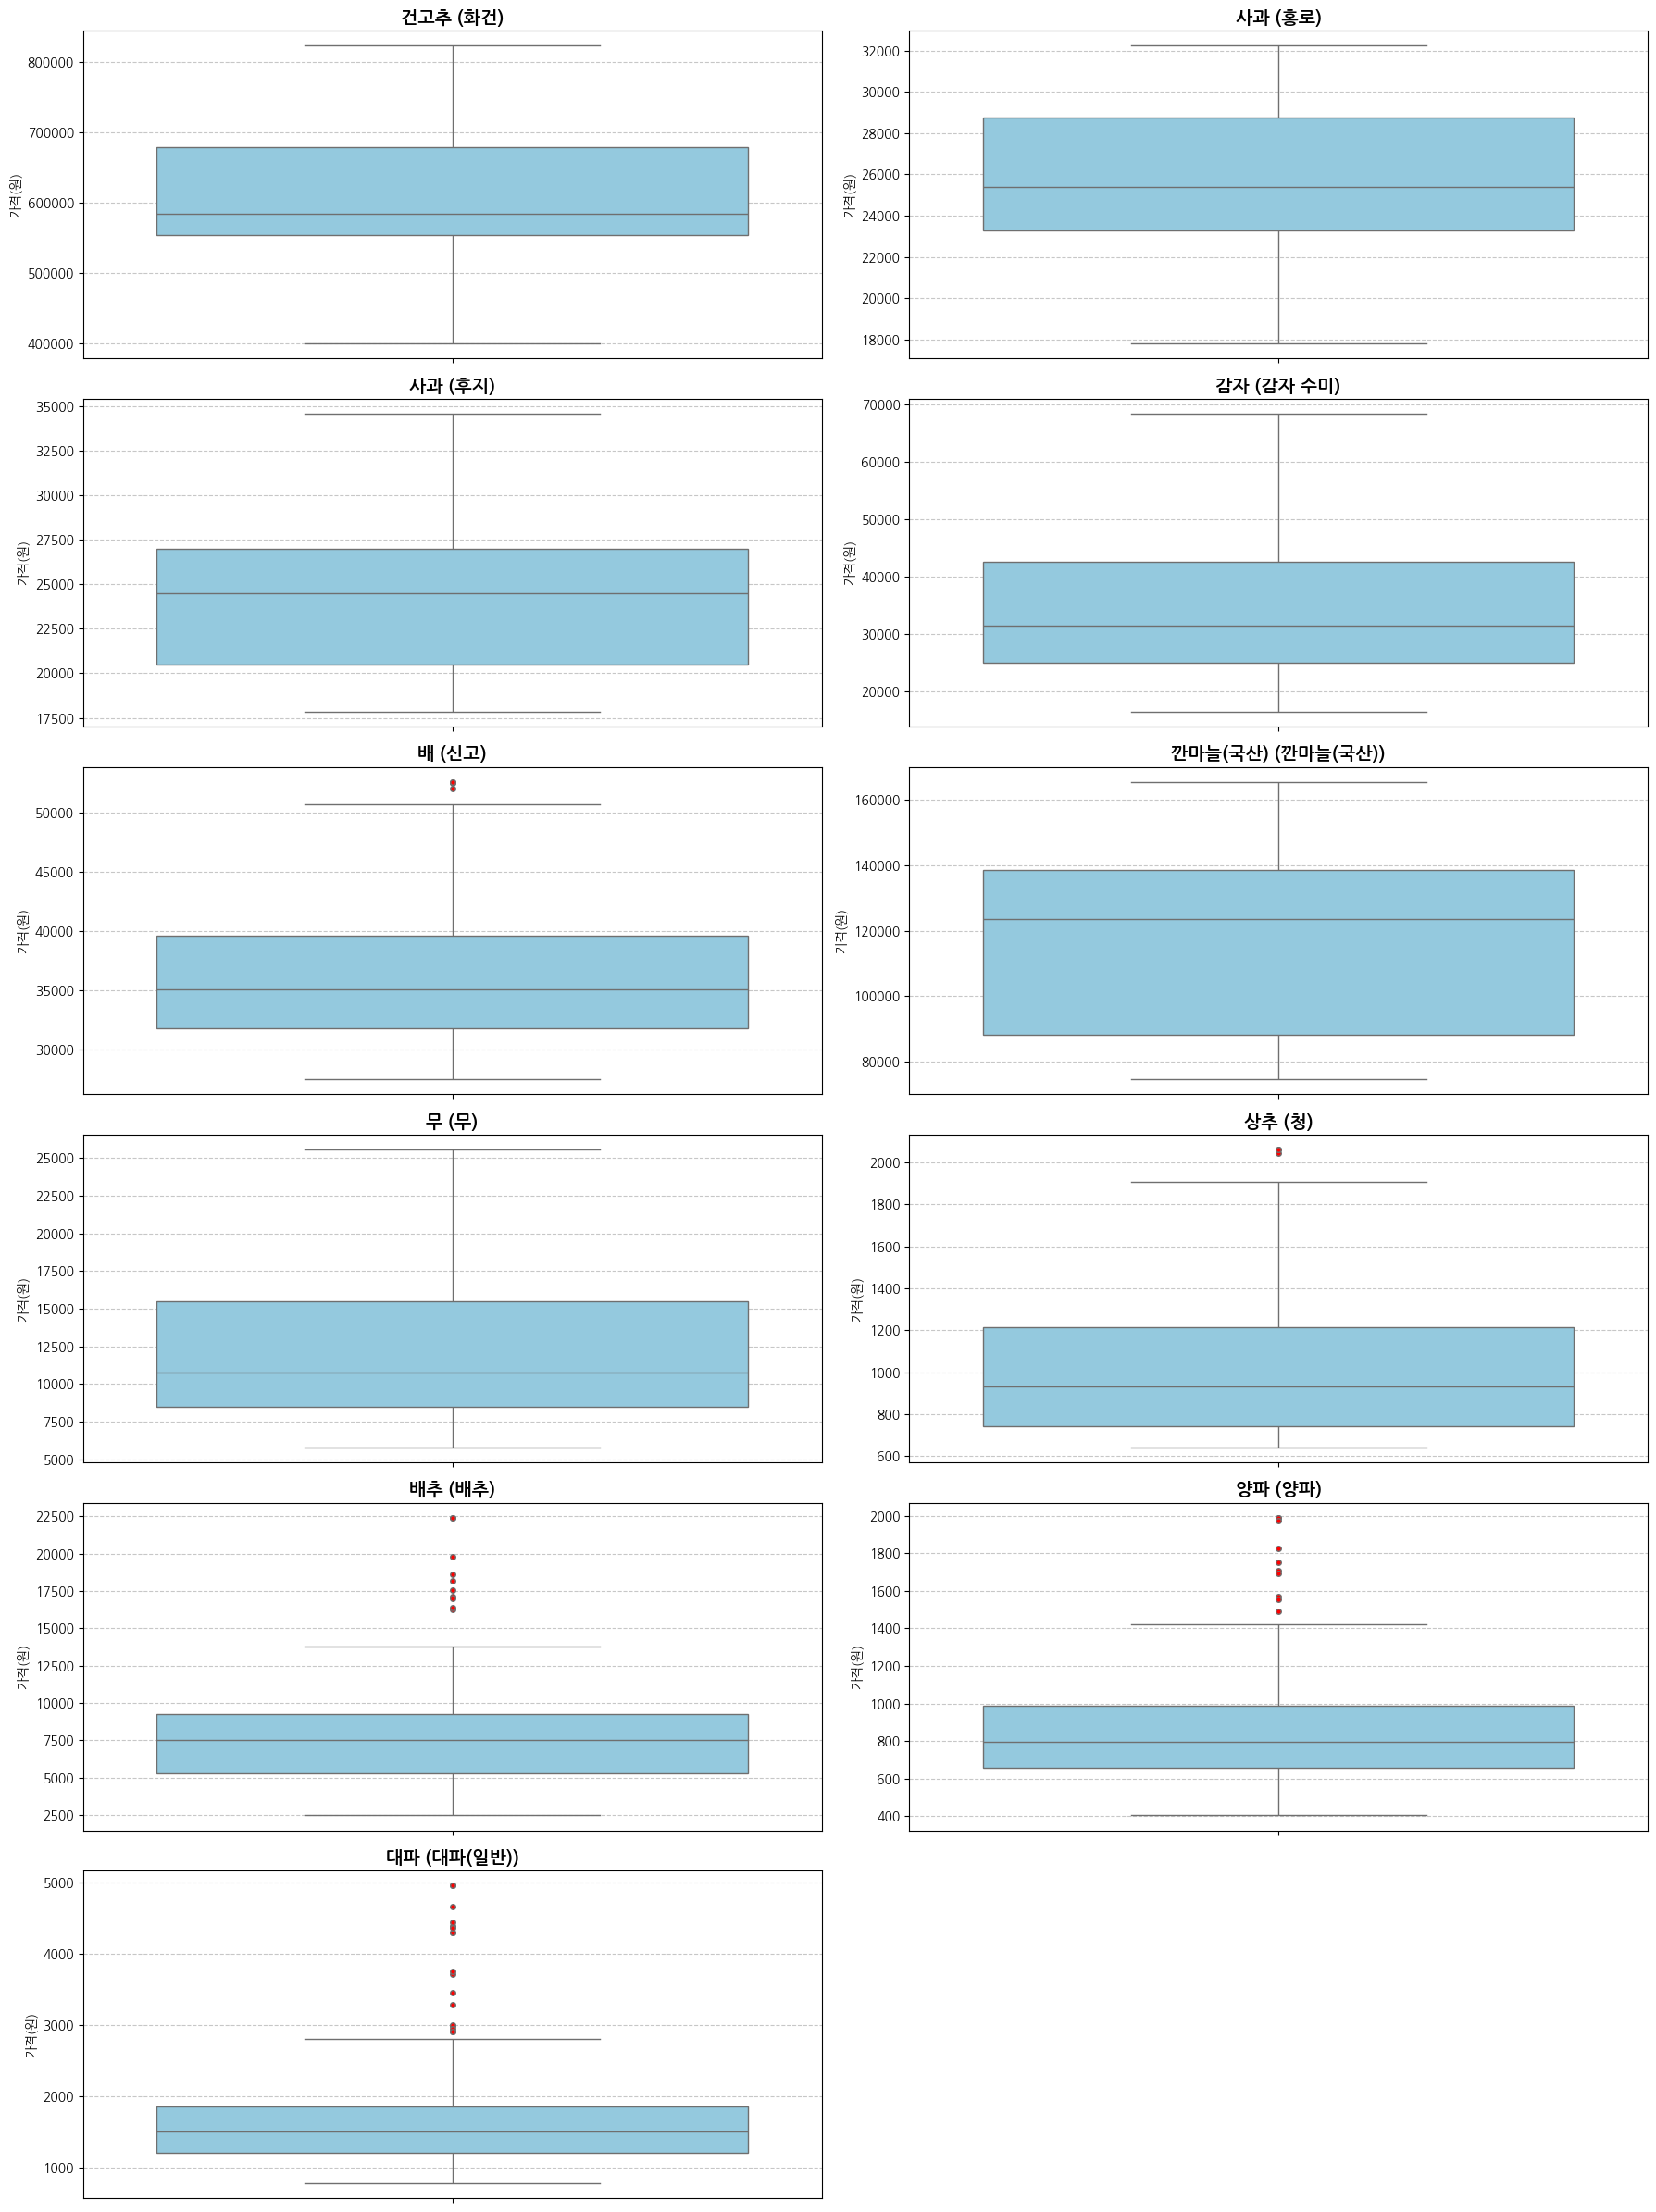

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # 박스플롯을 더 예쁘게 그려주는 라이브러리

# 1. 한글 폰트 설정 (나눔고딕)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 정제된 타겟 데이터 로드 (상하한가 1% 컷팅 완료된 파일)
base_path = './data/train/'
df = pd.read_csv(base_path + 'train_target_only_cleaned.csv')

# 가격 데이터 숫자형 변환 (안전장치)
price_col = df.columns[-1]
if df[price_col].dtype == 'object':
    df[price_col] = df[price_col].astype(str).str.replace(',', '')
df[price_col] = pd.to_numeric(df[price_col], errors='coerce')

# 3. 보기 편하게 '품목명 + 품종명'으로 통합 라벨 생성
df['타겟_라벨'] = df['품목명'] + ' (' + df['품종명'] + ')'
target_labels = df['타겟_라벨'].unique()

# 4. 6x2 서브플롯 그리드 생성
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(18, 24))
axes = axes.flatten()

# 5. 품목별로 박스플롯 그리기
for i, label in enumerate(target_labels):
    ax = axes[i]

    # 해당 품목 데이터 필터링
    plot_data = df[df['타겟_라벨'] == label]

    # Seaborn을 이용해 가독성 좋은 박스플롯 생성
    sns.boxplot(y=price_col, data=plot_data, ax=ax,
                color='skyblue',
                flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 4})

    # 그래프 꾸미기
    ax.set_title(f'{label}', fontsize=14, fontweight='bold')
    ax.set_ylabel('가격(원)')
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# 6. 남는 빈 캔버스 지우기
for j in range(len(target_labels), len(axes)):
    fig.delaxes(axes[j])

# 7. 출력
plt.tight_layout()
plt.show()

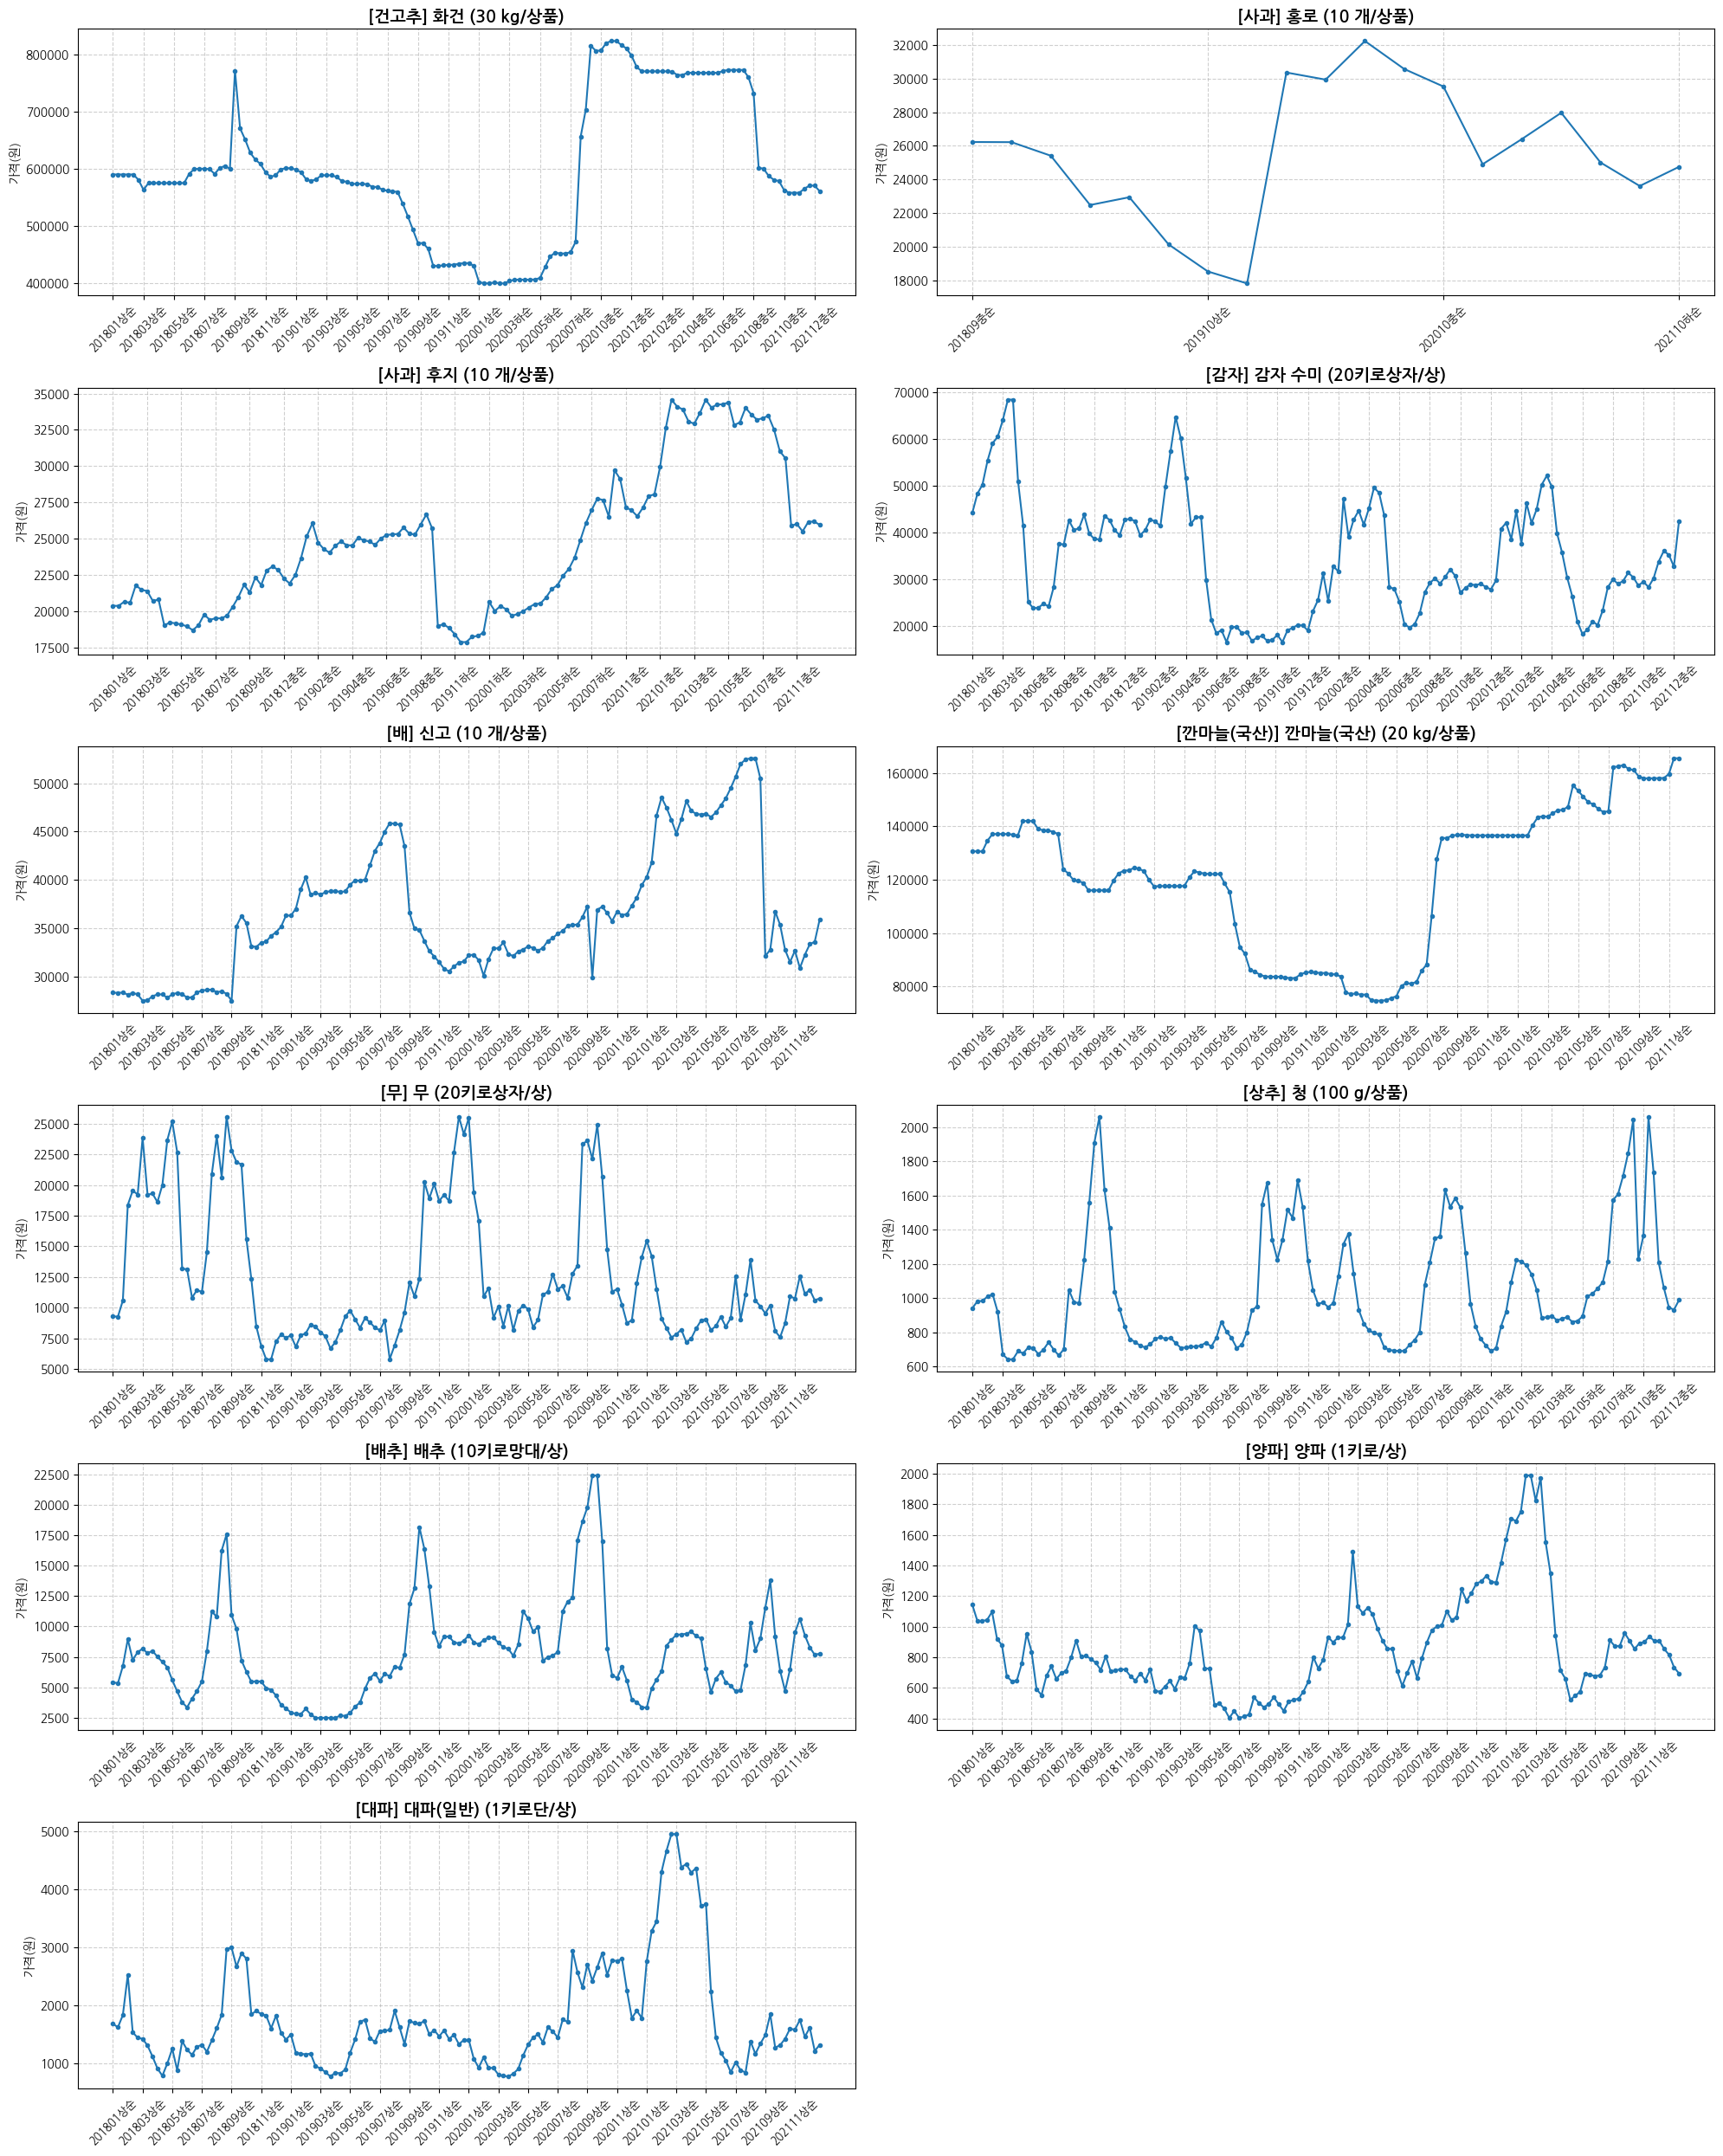

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. 폰트 설정 (나눔고딕)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 타겟 전용 데이터 로드
base_path = './data/train/'
df = pd.read_csv(base_path + 'train_target_only_cleaned.csv')

# 3. Y축(가격)만 숫자로 깔끔하게 변환 (콤마 제거)
price_col = df.columns[-1]
if df[price_col].dtype == 'object':
    df[price_col] = df[price_col].astype(str).str.replace(',', '')
df[price_col] = pd.to_numeric(df[price_col], errors='coerce')

# 가격이 없는 찌꺼기 데이터는 시각화에서 제외
df = df.dropna(subset=['시점', price_col])

# 4. 고유한 타겟 그룹 식별
target_groups = df[['품목명', '품종명', '거래단위', '등급']].drop_duplicates().values.tolist()

# 5. 시각화 그리기
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(20, 25))
axes = axes.flatten()

for i, (p, v, u, g) in enumerate(target_groups):
    ax = axes[i]

    # 데이터 필터링
    plot_df = df[(df['품목명'] == p) & (df['품종명'] == v) & \
                 (df['거래단위'] == u) & (df['등급'] == g)].copy()

    plot_df = plot_df.sort_values('시점')

    # X축 문자열 그대로, Y축 가격으로 선 그래프 그리기
    ax.plot(plot_df['시점'], plot_df[price_col], marker='o', markersize=3, color='tab:blue', linewidth=1.5)

    # 그래프 꾸미기
    ax.set_title(f'[{p}] {v} ({u}/{g})', fontsize=14, fontweight='bold')
    ax.set_ylabel('가격(원)')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ticks = ax.get_xticks()
    ax.set_xticks(ticks[::6])

# 남는 빈 그래프 공간 지우기
if len(target_groups) < len(axes):
    for j in range(len(target_groups), len(axes)):
        fig.delaxes(axes[j])

# 화면 출력
plt.tight_layout()
plt.show()